In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.cluster import KMeans

# Setting a unique Seaborn style for visualization
sns.set(style="whitegrid")


In [ ]:
from google.colab import files
uploaded=files.upload()

Saving US_Regional_Sales_Data01.csv to US_Regional_Sales_Data01.csv


In [ ]:
from sklearn import datasets
df = pd.read_csv('/content/US_Regional_Sales_Data.csv')

In [ ]:

# Display first few rows and basic data overview
print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset Summary:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


First 5 rows of the dataset:
   OrderNumber Sales Channel WarehouseCode ProcuredDate   OrderDate  \
0  SO - 000101      In-Store  WARE-UHY1004   12/31/2017  05/31/2018   
1  SO - 000102        Online  WARE-NMK1003   12/31/2017  05/31/2018   
2  SO - 000103   Distributor  WARE-UHY1004   12/31/2017  05/31/2018   
3  SO - 000104     Wholesale  WARE-NMK1003   12/31/2017  05/31/2018   
4  SO - 000105   Distributor  WARE-NMK1003   04/10/2018  05/31/2018   

     ShipDate DeliveryDate CurrencyCode  _SalesTeamID  _CustomerID  _StoreID  \
0  06/14/2018   06/19/2018          USD             6           15       259   
1  06/22/2018   07/02/2018          USD            14           20       196   
2  06/21/2018   07/01/2018          USD            21           16       213   
3  06/02/2018   06/07/2018          USD            28           48       107   
4  06/16/2018   06/26/2018          USD            22           49       111   

   _ProductID  Order Quantity  Discount Applied  Unit Price  Un

In [ ]:
df.shape

(7991, 16)

In [ ]:
df.nunique()

,0
OrderNumber,7991
Sales Channel,4
WarehouseCode,6
ProcuredDate,11
OrderDate,945
ShipDate,966
DeliveryDate,966
CurrencyCode,1
_SalesTeamID,28
_CustomerID,50


In [ ]:
df=df.drop(['OrderNumber','CurrencyCode'],axis=1)
df.head()

,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,_SalesTeamID,_CustomerID,_StoreID,_ProductID,Order Quantity,Discount Applied,Unit Price,Unit Cost
0,In-Store,WARE-UHY1004,12/31/2017,05/31/2018,06/14/2018,06/19/2018,6,15,259,12,5,0.075,1963.1,1001.181
1,Online,WARE-NMK1003,12/31/2017,05/31/2018,06/22/2018,07/02/2018,14,20,196,27,3,0.075,3939.6,3348.660
2,Distributor,WARE-UHY1004,12/31/2017,05/31/2018,06/21/2018,07/01/2018,21,16,213,16,1,0.050,1775.5,781.220
3,Wholesale,WARE-NMK1003,12/31/2017,05/31/2018,06/02/2018,06/07/2018,28,48,107,23,8,0.075,2324.9,1464.687
4,Distributor,WARE-NMK1003,04/10/2018,05/31/2018,06/16/2018,06/26/2018,22,49,111,26,8,0.100,1822.4,1476.144


In [ ]:
df['WarehouseCode'].unique()

array(['WARE-UHY1004', 'WARE-NMK1003', 'WARE-PUJ1005', 'WARE-XYS1001',
       'WARE-MKL1006', 'WARE-NBV1002'], dtype=object)

In [ ]:
df.columns

Index(['Sales Channel', 'WarehouseCode', 'ProcuredDate', 'OrderDate',
       'ShipDate', 'DeliveryDate', '_SalesTeamID', '_CustomerID', '_StoreID',
       '_ProductID', 'Order Quantity', 'Discount Applied', 'Unit Price',
       'Unit Cost'],
      dtype='object')

In [ ]:
date = df[['ProcuredDate', 'OrderDate','ShipDate', 'DeliveryDate']]
date

,ProcuredDate,OrderDate,ShipDate,DeliveryDate
0,12/31/2017,05/31/2018,06/14/2018,06/19/2018
1,12/31/2017,05/31/2018,06/22/2018,07/02/2018
2,12/31/2017,05/31/2018,06/21/2018,07/01/2018
3,12/31/2017,05/31/2018,06/02/2018,06/07/2018
4,04/10/2018,05/31/2018,06/16/2018,06/26/2018
...,...,...,...,...
7986,09/26/2020,12/30/2020,01/07/2021,01/14/2021
7987,09/26/2020,12/30/2020,01/02/2021,01/04/2021
7988,09/26/2020,12/30/2020,01/23/2021,01/26/2021
7989,09/26/2020,12/30/2020,01/20/2021,01/25/2021


In [ ]:
date.head()

,ProcuredDate,OrderDate,ShipDate,DeliveryDate
0,12/31/2017,05/31/2018,06/14/2018,06/19/2018
1,12/31/2017,05/31/2018,06/22/2018,07/02/2018
2,12/31/2017,05/31/2018,06/21/2018,07/01/2018
3,12/31/2017,05/31/2018,06/02/2018,06/07/2018
4,04/10/2018,05/31/2018,06/16/2018,06/26/2018


In [ ]:
# Convert 'DeliveryDate' and 'OrderDate' to datetime objects
date['DeliveryDate'] = pd.to_datetime(date['DeliveryDate'])
date['OrderDate'] = pd.to_datetime(date['OrderDate'])

# Now calculate the delay
delay = date['DeliveryDate'] - date['OrderDate']
delay

<ipython-input-28-f5bc02505cbb>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date['DeliveryDate'] = pd.to_datetime(date['DeliveryDate'])
<ipython-input-28-f5bc02505cbb>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date['OrderDate'] = pd.to_datetime(date['OrderDate'])


,0
0,19 days
1,32 days
2,31 days
3,7 days
4,26 days
...,...
7986,15 days
7987,5 days
7988,27 days
7989,26 days


In [ ]:
# Convert 'ProcuredDate', 'OrderDate' to datetime objects
date['ProcuredDate'] = pd.to_datetime(date['ProcuredDate'])
date['OrderDate'] = pd.to_datetime(date['OrderDate'])

# Now calculate shelf_duration
shelf_duration = date['OrderDate'] - date['ProcuredDate']
shelf_duration

<ipython-input-29-23a1f122f6ae>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date['ProcuredDate'] = pd.to_datetime(date['ProcuredDate'])
<ipython-input-29-23a1f122f6ae>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date['OrderDate'] = pd.to_datetime(date['OrderDate'])


,0
0,151 days
1,151 days
2,151 days
3,151 days
4,51 days
...,...
7986,95 days
7987,95 days
7988,95 days
7989,95 days


In [ ]:
date['delivery_delay'] = pd.Series(delay)
date['shelf_duration'] = pd.Series(shelf_duration)
date.head()

<ipython-input-30-ea0e93606ae4>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date['delivery_delay'] = pd.Series(delay)
<ipython-input-30-ea0e93606ae4>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date['shelf_duration'] = pd.Series(shelf_duration)


,ProcuredDate,OrderDate,ShipDate,DeliveryDate,delivery_delay,shelf_duration
0,2017-12-31,2018-05-31,06/14/2018,2018-06-19,19 days,151 days
1,2017-12-31,2018-05-31,06/22/2018,2018-07-02,32 days,151 days
2,2017-12-31,2018-05-31,06/21/2018,2018-07-01,31 days,151 days
3,2017-12-31,2018-05-31,06/02/2018,2018-06-07,7 days,151 days
4,2018-04-10,2018-05-31,06/16/2018,2018-06-26,26 days,51 days


In [ ]:
date['delivery_delay'] = date['delivery_delay'].apply(lambda x:int(str(x).split(' ')[0]))
date['shelf_duration'] = date['shelf_duration'].apply(lambda x:int(str(x).split(' ')[0]))

<ipython-input-31-4a67d0ab5ab8>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date['delivery_delay'] = date['delivery_delay'].apply(lambda x:int(str(x).split(' ')[0]))
<ipython-input-31-4a67d0ab5ab8>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date['shelf_duration'] = date['shelf_duration'].apply(lambda x:int(str(x).split(' ')[0]))


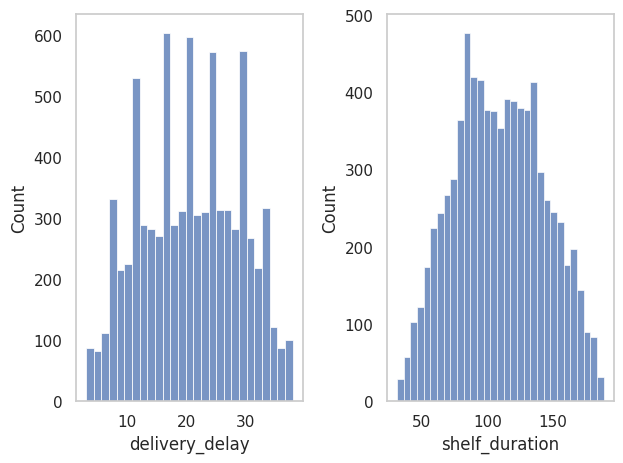

In [ ]:
plt.subplot(1,2,1)
sns.histplot(date['delivery_delay'])
plt.grid()
plt.subplot(1,2,2)
sns.histplot(date['shelf_duration'])
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
for i in df[['_SalesTeamID', '_CustomerID', '_StoreID','_ProductID']].columns:
    print("The no.of unique values in {} are: {}".format(i,df[i].nunique()))

The no.of unique values in _SalesTeamID are: 28
The no.of unique values in _CustomerID are: 50
The no.of unique values in _StoreID are: 367
The no.of unique values in _ProductID are: 47


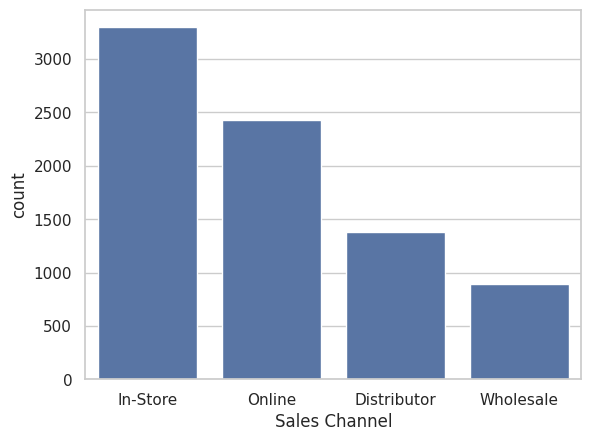

In [ ]:
sns.countplot(x='Sales Channel',data=df)
plt.show()

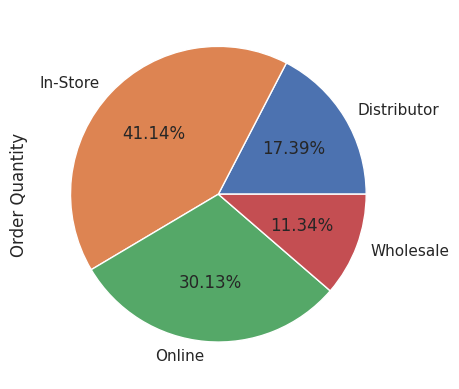

In [ ]:
df.groupby('Sales Channel')['Order Quantity'].sum().plot(kind='pie',autopct='%0.2f%%')
plt.show()